In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.constants import elementary_charge, Boltzmann

In [20]:
# Constantes necesarias

# Hz,  el valor de 1/t_0
t_0 = 10**13

# eV
E_a = 1

# Tiene distintos valores dependiendo si el estado es FORMING/SET y RESET
gamma = 3

# Valor de la constante de Boltzmann en eV/K
k_b_ev = Boltzmann / elementary_charge

# Factor de recombinación debido a la presencia de exceso de iones de oxígeno
beta_0 = 3e3

# Potencial de migración de los iones de oxígeno en eV
E_m = 1.0

# Coeficiente de deriva de los iones de oxígeno debido a la presencia de un campo eléctrico externo
gamma_drift = 8e9

# m, longitud de decaimiento de la concentración de oxígeno
L_p = 1e-9

In [21]:
def DifussiveBehaviour(pos_x: int, Oxigen_Ion_velocity: float, Simulation_time: float, grid_size: float = 0.25e-9,) -> float:
    """
    Calculates the diffusion behavior based on the given parameters.

    Parameters:
    - pos_x (int): The position of the diffusion event.
    - Oxigen_Ion_velocity (float): The velocity of the oxygen ion.
    - Simulation_time (float): The simulation time.
    - grid_size (float, optional): The size of the grid. Default is 0.25e-9.

    Returns:
    - float: The diffusion value based on the given conditions.
    """

    vt = Oxigen_Ion_velocity * Simulation_time
    print('\nEl producto del tiempo por la velocidad de ion es: {:.2e}\n'.format(vt))
    pos_x = pos_x * grid_size
    print('La posicion del ion es: {:.2e}\n'.format(pos_x))

    condiciones = [
        pos_x <= vt,
        (vt < pos_x) and (pos_x <= vt + grid_size),
        (vt + grid_size < pos_x) and (pos_x <= vt + 3 * grid_size),
        (pos_x > vt + 3 * grid_size),
    ]

    # Imprimo los valores de las condiciones
    print('Las condiciones son:')
    print(condiciones)

    # Imprimno de forma bonita los valores numericos de las condiciones
    print('\nLos valores de las condiciones son:')
    print('1. {:.2e}'.format(pos_x))
    print('2. {:.2e}'.format(vt))
    print('3. {:.2e}'.format(vt + grid_size))
    print('4. {:.2e}\n'.format(vt + 3 * grid_size))

    valores_Difusion = [1, 0.3, 0.1, 0]

    print('La constante de difusion es: {:.2e}\n'.format(np.piecewise(pos_x, condiciones, valores_Difusion)))

    return np.piecewise(pos_x, condiciones, valores_Difusion)

In [22]:
def recombination(simulation_time: float, pos_x: int, electric_field: float, temperature: float, grid_size=0.25e-9,) -> float:

    Oxigen_Ion_velocity = (t_0 * grid_size
                           * math.exp(-E_m / (k_b_ev * temperature))
                           * math.sinh((2 * elementary_charge * electric_field * gamma_drift)
                                       / (k_b_ev * temperature)))

    print('La exponencial vale: {:.2e}\n'.format(math.exp(-E_m / (k_b_ev * temperature))))
    print('El seno hiperbólico vale: {:.2e}\n'.format(
        math.sinh((2 * elementary_charge * electric_field * gamma_drift)/(k_b_ev * temperature))))

    # Escribo con un buen formato el valor de la velocidad del ion de oxígeno
    print('La velocidad del ion de oxígeno es: {:.2e}'.format(Oxigen_Ion_velocity))

    Prob_in_equilibrio = (simulation_time * t_0) * (math.exp(-E_a / (k_b_ev * temperature)))
    print('La probabilidad en equilibrio es: {:.2e}'.format(Prob_in_equilibrio))

    Recombination_Probability = (beta_0
                                 * (math.exp(-simulation_time * Oxigen_Ion_velocity / L_p))
                                 * DifussiveBehaviour(pos_x, Oxigen_Ion_velocity, simulation_time, grid_size))

    print('La probabilidad de recombinación es: {:.2e}\n'.format(Recombination_Probability))

    return Prob_in_equilibrio * Recombination_Probability

In [23]:
# Creo vectores para el campo eléctrico, temperatura y tiempo de simulación.

potencial = np.linspace(0, 1, 100)
electric_field = potencial / (10e-9)

# print(electric_field)

temperature = np.linspace(200, 400, 100)
simulation_time = np.linspace(0, 1, 100)

pos_x = np.linspace(0, 40, 41, dtype=int)

Calculando la probabilidad de recombinación para la posición 0 y el campo eléctrico 0.0
La exponencial vale: 3.99e-15

El seno hiperbólico vale: 0.00e+00

La velocidad del ion de oxígeno es: 0.00e+00
La probabilidad en equilibrio es: 3.99e-02

El producto del tiempo por la velocidad de ion es: 0.00e+00

La posicion del ion es: 0.00e+00

Las condiciones son:
[True, False, False, False]

Los valores de las condiciones son:
1. 0.00e+00
2. 0.00e+00
3. 2.50e-10
4. 7.50e-10

La constante de difusion es: 1.00e+00

La probabilidad de recombinación es: 3.00e+03

Calculando la probabilidad de recombinación para la posición 0 y el campo eléctrico 1010101.0101010102
La exponencial vale: 3.99e-15

El seno hiperbólico vale: 8.60e-02

La velocidad del ion de oxígeno es: 8.57e-13
La probabilidad en equilibrio es: 3.99e-02

El producto del tiempo por la velocidad de ion es: 8.57e-13

La posicion del ion es: 0.00e+00

Las condiciones son:
[True, False, False, False]

Los valores de las condiciones son:


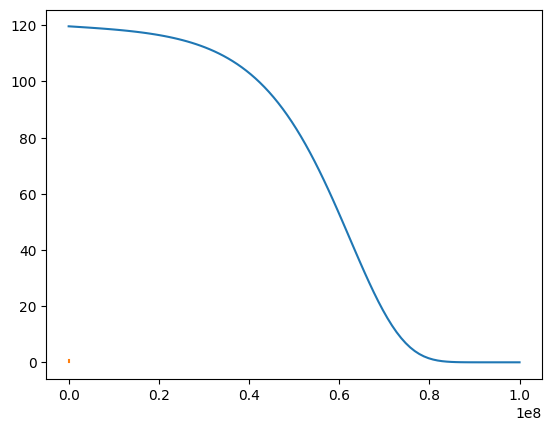

In [24]:
# Calculo la probabilidad de recombinación en función de la posición y lo guardo en un vector
prob_recombination_pos = np.zeros((41, 100))

# Calculo la probabilidad de recombinación en función de la posición
for i in pos_x:
    for j in range(100):
        print('Calculando la probabilidad de recombinación para la posición {} y el campo eléctrico {}'.format(
            i, electric_field[j]))
        prob_recombination_pos[i][j] = recombination(1, i, float(electric_field[j]), 350)


plt.plot(electric_field, prob_recombination_pos[0, :])
plt.plot(pos_x, prob_recombination_pos[:, 80])